# Pipeline step 04 — ROI analysis (β / t across TRs)

**Purpose:** sample the per-subject GLM β and t maps (from steps 02 / 02b) inside
6 mm spheres at the hMT+ / V1 seeds (step-03), for every subject × TR × contrast,
and write tidy tables to `data/nilearn-roianalysis-*.tsv`.

**Manuscript output:** Figure 3 (β and t across TRs for motion / coherent /
incoherent − static; UA-only panels are supplementary). The maskers use no
temporal filtering or standardization because they sample statistic maps, not
time series.

# Extract ROI information [sim01]
Betas, T values, Z values

In [33]:
import os
import numpy as np
import pandas as pd
from nilearn.maskers import NiftiSpheresMasker

In [34]:
# Settings
data_dir = "/DATAPOOL/VPMB/BIDS-VPMB-SPE"
# fmriprep_dir = os.path.join(data_dir,'derivatives','fmriprep23','fmriprep')
nilearn_dir = os.path.join(data_dir, "derivatives", "nilearn_glm")
# output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')
out_dir = "/DATAPOOL/home/alexandresayal/GitRepos/vpmb-tr/data"

subject_list = [x for x in os.listdir(data_dir) if "sub-" in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
tr_label_list = ["0500", "0750", "1000", "2500"]
# n_volumes_list = [780, 520, 390, 156]
run_list = ["AA", "UA"]
# hrf_delay = 3 # in seconds

In [35]:
# Load subject-specific roi coordinates
roi_ss_coords = pd.read_csv(
    os.path.join(nilearn_dir, "group", "roi_ss_matrix.txt"),
    sep="\t",
    header=None,
    names=[
        "left_mt_x",
        "left_mt_y",
        "left_mt_z",
        "right_mt_x",
        "right_mt_y",
        "right_mt_z",
        "left_v1_x",
        "left_v1_y",
        "left_v1_z",
        "right_v1_x",
        "right_v1_y",
        "right_v1_z",
    ],
)

# add new column with the subject names
roi_ss_coords["subject"] = subject_list
roi_labels = ["hMT+ L", "hMT+ R", "V1 L", "V1 R"]

In [36]:
# Initialize matrix to store the beta values of all subjects per tr
BETAS = np.zeros((len(subject_list), len(tr_list), len(run_list), len(roi_labels)))
TVALS = np.zeros((len(subject_list), len(tr_list), len(run_list), len(roi_labels)))
ZVALS = np.zeros((len(subject_list), len(tr_list), len(run_list), len(roi_labels)))

In [37]:
# Create combinations of subject, tr and run
C = []
for ss, subject in enumerate(subject_list):
    # extract x,y,z coordinates of this subject's hMT+ roi
    cluster_coords = [[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0]]
    cluster_coords[0] = roi_ss_coords[roi_ss_coords["subject"] == subject].iloc[:, 0:3].values[0].tolist()
    cluster_coords[1] = roi_ss_coords[roi_ss_coords["subject"] == subject].iloc[:, 3:6].values[0].tolist()
    cluster_coords[2] = roi_ss_coords[roi_ss_coords["subject"] == subject].iloc[:, 6:9].values[0].tolist()
    cluster_coords[3] = roi_ss_coords[roi_ss_coords["subject"] == subject].iloc[:, 9:12].values[0].tolist()

    C.append([ss, subject, cluster_coords])

C

[[0, 'sub-01', [[-46, -70, 14], [46, -76, 6], [-10, -98, 0], [18, -96, 2]]],
 [1, 'sub-02', [[-50, -70, 14], [52, -68, 8], [-14, -98, 4], [14, -96, -8]]],
 [2, 'sub-03', [[-44, -62, 0], [48, -64, 0], [-4, -94, -6], [16, -82, -4]]],
 [3, 'sub-05', [[-46, -70, 8], [48, -64, 6], [-6, -92, -4], [18, -92, -8]]],
 [4, 'sub-06', [[-46, -66, 12], [48, -68, 6], [-12, -96, 2], [16, -96, 0]]],
 [5, 'sub-07', [[-46, -72, 4], [54, -66, 4], [-10, -88, -8], [20, -88, -4]]],
 [6, 'sub-08', [[-42, -78, 12], [46, -72, 4], [-8, -96, -4], [14, -86, -4]]],
 [7, 'sub-10', [[-46, -72, 0], [52, -66, 6], [-8, -90, -6], [16, -98, 0]]],
 [8, 'sub-11', [[-44, -76, -4], [50, -68, -8], [-18, -90, -8], [16, -84, -8]]],
 [9, 'sub-12', [[-42, -72, 2], [48, -72, 2], [-10, -98, -10], [16, -98, 0]]],
 [10, 'sub-15', [[-40, -80, -2], [50, -70, -4], [-6, -100, 6], [16, -94, 2]]],
 [11, 'sub-16', [[-40, -66, 6], [44, -62, 6], [-12, -100, 4], [16, -92, 2]]],
 [12, 'sub-21', [[-50, -66, 4], [52, -64, 8], [-14, -84, -10], [12,

In [38]:
# contrast naming
contrast_name_valid = "incoherentMinusStatic"  # "motionMinusStatic", 'coherentMinusStatic', 'incoherentMinusStatic', "coherentMinusIncoherent"

for ss in range(len(subject_list)):
    print(f"Subject: {subject_list[ss]}")

    masker = NiftiSpheresMasker(seeds=C[ss][2], radius=6, detrend=False, standardize=False, low_pass=None, high_pass=None, resampling_target=None)

    masker.fit()

    for tr in range(len(tr_list)):
        for rr in range(len(run_list)):
            # if beta_img does not exist, fill the matrix with nan. this is necessary because sub-11 TR=2.5 does not contain incoherent trials.
            beta_img = os.path.join(
                nilearn_dir, f"{subject_list[ss]}_task-{run_list[rr]}_acq-{tr_label_list[tr]}_stat-beta_con-{contrast_name_valid}.nii.gz"
            )

            if not os.path.exists(beta_img):
                BETAS[ss, tr, rr, :] = np.nan
                TVALS[ss, tr, rr, :] = np.nan
                ZVALS[ss, tr, rr, :] = np.nan

            else:  # proceed as usual
                t_img = os.path.join(
                    nilearn_dir, f"{subject_list[ss]}_task-{run_list[rr]}_acq-{tr_label_list[tr]}_stat-t_con-{contrast_name_valid}.nii.gz"
                )

                z_img = os.path.join(
                    nilearn_dir, f"{subject_list[ss]}_task-{run_list[rr]}_acq-{tr_label_list[tr]}_stat-z_con-{contrast_name_valid}.nii.gz"
                )

                BETAS[ss, tr, rr, :] = masker.fit_transform(beta_img)[0]
                TVALS[ss, tr, rr, :] = masker.fit_transform(t_img)[0]
                ZVALS[ss, tr, rr, :] = masker.fit_transform(z_img)[0]

Subject: sub-01
Subject: sub-02
Subject: sub-03
Subject: sub-05
Subject: sub-06
Subject: sub-07
Subject: sub-08
Subject: sub-10
Subject: sub-11
Subject: sub-12
Subject: sub-15
Subject: sub-16
Subject: sub-21
Subject: sub-22
Subject: sub-23


In [39]:
# save 4D matrices as npy files
np.save(os.path.join(out_dir, f"BETAS_{contrast_name_valid}.npy"), BETAS)
np.save(os.path.join(out_dir, f"TVALS_{contrast_name_valid}.npy"), TVALS)
np.save(os.path.join(out_dir, f"ZVALS_{contrast_name_valid}.npy"), ZVALS)

In [40]:
# convert BETAS to a dataframe with the following columns: subject, tr, task, roi, beta
DF = pd.DataFrame(columns=["subject", "tr", "task", "roi", "beta", "tval", "zval"])
idx = 0
for ss, subject in enumerate(subject_list):
    for tt, tr in enumerate(tr_label_list):
        for ta, task in enumerate(run_list):
            for rr, roi in enumerate(roi_labels):
                beta = BETAS[ss, tt, ta, rr]
                tval = TVALS[ss, tt, ta, rr]
                zval = ZVALS[ss, tt, ta, rr]
                DF.loc[idx] = [subject, tr, task, roi, beta, tval, zval]
                idx += 1

In [41]:
DF

,subject,tr,task,roi,beta,tval,zval
0,sub-01,0500,AA,hMT+ L,0.860989,4.388957,4.355988
1,sub-01,0500,AA,hMT+ R,0.722579,3.090423,3.073642
2,sub-01,0500,AA,V1 L,-0.546948,-2.203022,-2.198284
3,sub-01,0500,AA,V1 R,-0.362857,-1.846989,-1.843899
4,sub-01,0500,UA,hMT+ L,1.034471,5.483909,5.420918
...,...,...,...,...,...,...,...
475,sub-23,2500,AA,V1 R,0.222360,0.840363,0.835643
476,sub-23,2500,UA,hMT+ L,0.599949,1.981135,1.910496
477,sub-23,2500,UA,hMT+ R,0.741327,2.988768,2.888535
478,sub-23,2500,UA,V1 L,0.387713,1.695874,1.676986


In [42]:
# save dataframe
DF.to_csv(os.path.join("..", "data", f"nilearn-roianalysis-AAUA-{contrast_name_valid}.tsv"), sep="\t", index=False)

# Load

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statannotations.Annotator import Annotator

TRs = [500, 750, 1000, 2500]
TR_pairs = list(combinations(TRs, r=2))

# contrast_name_valid = "incoherentMinusStatic"  # "motionMinusStatic", 'coherentMinusStatic', 'incoherentMinusStatic', 'coherentMinusIncoherent'

# roi_labels = ['hMT+ L', 'hMT+ R', 'V1 L', 'V1 R']
roi_labels = ["hMT+", "V1"]
sns.set_theme(style="ticks")

## hMT+ big figure

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.210e-02 U_stat=1.780e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.135e-03 U_stat=2.030e+02
p-value 

(<Axes: title={'center': 'incoherent'}, xlabel='TR (s)', ylabel='t value'>,
  <statannotations.Annotation.Annotation at 0x7f31e9a5d6d0>])

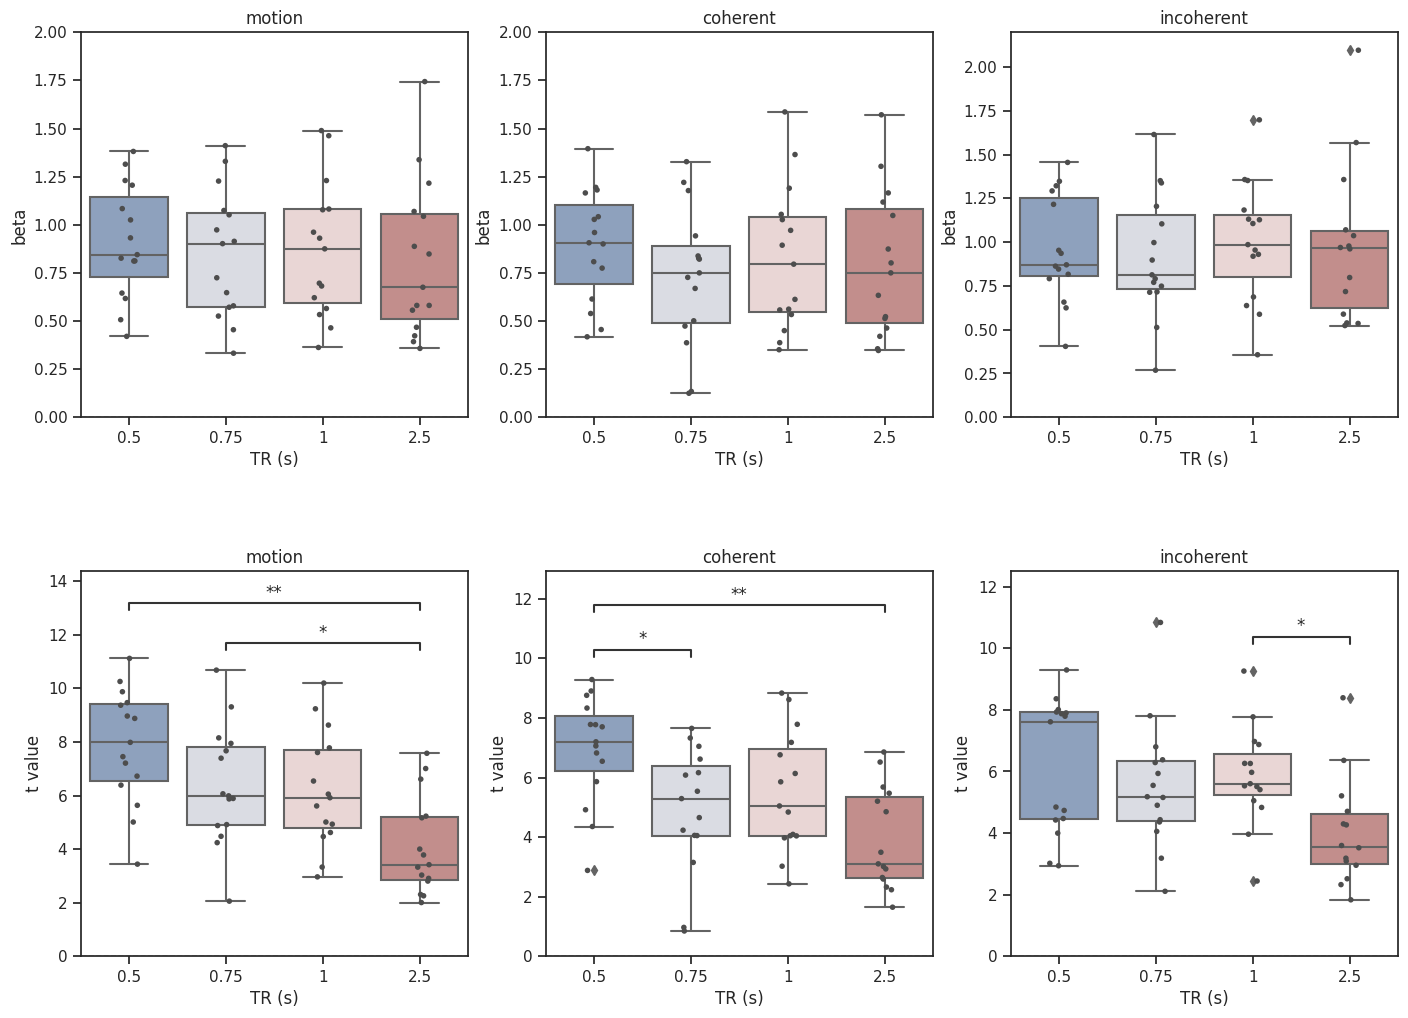

In [44]:
# Load dataframes for all contrasts to plot big figure
df1 = pd.read_csv(os.path.join("..", "data", "nilearn-roianalysis-AAUA-motionMinusStatic.tsv"), sep="\t")
df2 = pd.read_csv(os.path.join("..", "data", "nilearn-roianalysis-AAUA-coherentMinusStatic.tsv"), sep="\t")
df3 = pd.read_csv(os.path.join("..", "data", "nilearn-roianalysis-AAUA-incoherentMinusStatic.tsv"), sep="\t")

# Exclude all entried with task==AA
# df1 = df1[df1["task"] == "UA"]
# df2 = df2[df2["task"] == "UA"]
# df3 = df3[df3["task"] == "UA"]

# Remove task column
df1 = df1.drop(columns=["task"])
df2 = df2.drop(columns=["task"])
df3 = df3.drop(columns=["task"])

# "Average" 'roi'==hMT+ L and hMT+ R
df1.loc[df1["roi"] == "hMT+ L", "roi"] = "hMT+"
df1.loc[df1["roi"] == "hMT+ R", "roi"] = "hMT+"
df2.loc[df2["roi"] == "hMT+ L", "roi"] = "hMT+"
df2.loc[df2["roi"] == "hMT+ R", "roi"] = "hMT+"
df3.loc[df3["roi"] == "hMT+ L", "roi"] = "hMT+"
df3.loc[df3["roi"] == "hMT+ R", "roi"] = "hMT+"

# Average per subject, tr and roi
df1 = df1.groupby(["subject", "tr", "roi"]).mean().reset_index()
df2 = df2.groupby(["subject", "tr", "roi"]).mean().reset_index()
df3 = df3.groupby(["subject", "tr", "roi"]).mean().reset_index()

# Perform a 2x6 subplot figure - 2 rows for beta and t values, 3 columns for each contrast
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(17, 12), sharey=False)
plt.subplots_adjust(hspace=0.4)

# -------------- SUBPLOT 1 - beta - motionMinusStatic contrast ----------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="beta", data=df1.loc[df1["roi"] == "hMT+", :], size=4, color=".3", linewidth=0, ax=axes[0, 0])

# boxplot
aux = sns.boxplot(x="tr", y="beta", data=df1.loc[df1["roi"] == "hMT+", :], palette="vlag", ax=axes[0, 0])
aux.set_title("motion")
aux.set_ylim(0, 2)
aux.set_ylabel("beta")
aux.set_xlabel("TR (s)")

# edit x tick labels to seconds
aux.set_xticklabels(["0.5", "0.75", "1", "2.5"])

# line in y=0
axes[0, 0].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[0, 0], TR_pairs, data=df1.loc[df1["roi"] == "hMT+", :], x="tr", y="beta", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()

# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 2 - beta - coherentMinusStatic contrast ----------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="beta", data=df2.loc[df2["roi"] == "hMT+", :], size=4, color=".3", linewidth=0, ax=axes[0, 1])

# boxplot
aux = sns.boxplot(x="tr", y="beta", data=df2.loc[df2["roi"] == "hMT+", :], palette="vlag", ax=axes[0, 1])
aux.set_title("coherent")
aux.set_ylim(0, 2)
aux.set_ylabel("beta")
aux.set_xlabel("TR (s)")

# edit x tick labels to seconds
aux.set_xticklabels(["0.5", "0.75", "1", "2.5"])

# line in y=0
axes[0, 1].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[0, 1], TR_pairs, data=df2.loc[df2["roi"] == "hMT+", :], x="tr", y="beta", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 3 - beta - incoherentMinusStatic contrast --------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="beta", data=df3.loc[df3["roi"] == "hMT+", :], size=4, color=".3", linewidth=0, ax=axes[0, 2])

# boxplot
aux = sns.boxplot(x="tr", y="beta", data=df3.loc[df3["roi"] == "hMT+", :], palette="vlag", ax=axes[0, 2])
aux.set_title("incoherent")
aux.set_ylim(0, 2)
aux.set_ylabel("beta")
aux.set_xlabel("TR (s)")

# edit x tick labels to seconds
aux.set_xticklabels(["0.5", "0.75", "1", "2.5"])

# line in y=0
axes[0, 2].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[0, 2], TR_pairs, data=df3.loc[df3["roi"] == "hMT+", :], x="tr", y="beta", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 4 - tval - motionMinusStatic contrast ------------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="tval", data=df1.loc[df1["roi"] == "hMT+", :], size=4, color=".3", linewidth=0, ax=axes[1, 0])

# boxplot
aux = sns.boxplot(x="tr", y="tval", data=df1.loc[df1["roi"] == "hMT+", :], palette="vlag", ax=axes[1, 0])
aux.set_title("motion")
aux.set_ylim(0, 12.5)
aux.set_ylabel("t value")
aux.set_xlabel("TR (s)")

# edit x tick labels to seconds
aux.set_xticklabels(["0.5", "0.75", "1", "2.5"])

# line in y=0
axes[1, 0].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[1, 0], TR_pairs, data=df1.loc[df1["roi"] == "hMT+", :], x="tr", y="tval", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 5 - tval - coherentMinusStatic contrast ----------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="tval", data=df2.loc[df2["roi"] == "hMT+", :], size=4, color=".3", linewidth=0, ax=axes[1, 1])

# boxplot
aux = sns.boxplot(x="tr", y="tval", data=df2.loc[df2["roi"] == "hMT+", :], palette="vlag", ax=axes[1, 1])
aux.set_title("coherent")
aux.set_ylim(0, 12.5)
aux.set_ylabel("t value")
aux.set_xlabel("TR (s)")

# edit x tick labels to seconds
aux.set_xticklabels(["0.5", "0.75", "1", "2.5"])

# line in y=0
axes[1, 1].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[1, 1], TR_pairs, data=df2.loc[df2["roi"] == "hMT+", :], x="tr", y="tval", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 6 - tval - incoherentMinusStatic contrast --------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="tval", data=df3.loc[df3["roi"] == "hMT+", :], size=4, color=".3", linewidth=0, ax=axes[1, 2])

# boxplot
aux = sns.boxplot(x="tr", y="tval", data=df3.loc[df3["roi"] == "hMT+", :], palette="vlag", ax=axes[1, 2])
aux.set_title("incoherent")
aux.set_ylim(0, 12.5)
aux.set_ylabel("t value")
aux.set_xlabel("TR (s)")

# edit x tick labels to seconds
aux.set_xticklabels(["0.5", "0.75", "1", "2.5"])

# line in y=0
axes[1, 2].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[1, 2], TR_pairs, data=df3.loc[df3["roi"] == "hMT+", :], x="tr", y="tval", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()


## V1 big figure

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.0

(<Axes: title={'center': 'incoherent vs. static'}, xlabel='TR (ms)', ylabel='t value'>,
  <statannotations.Annotation.Annotation at 0x7fa8f58ecaf0>])

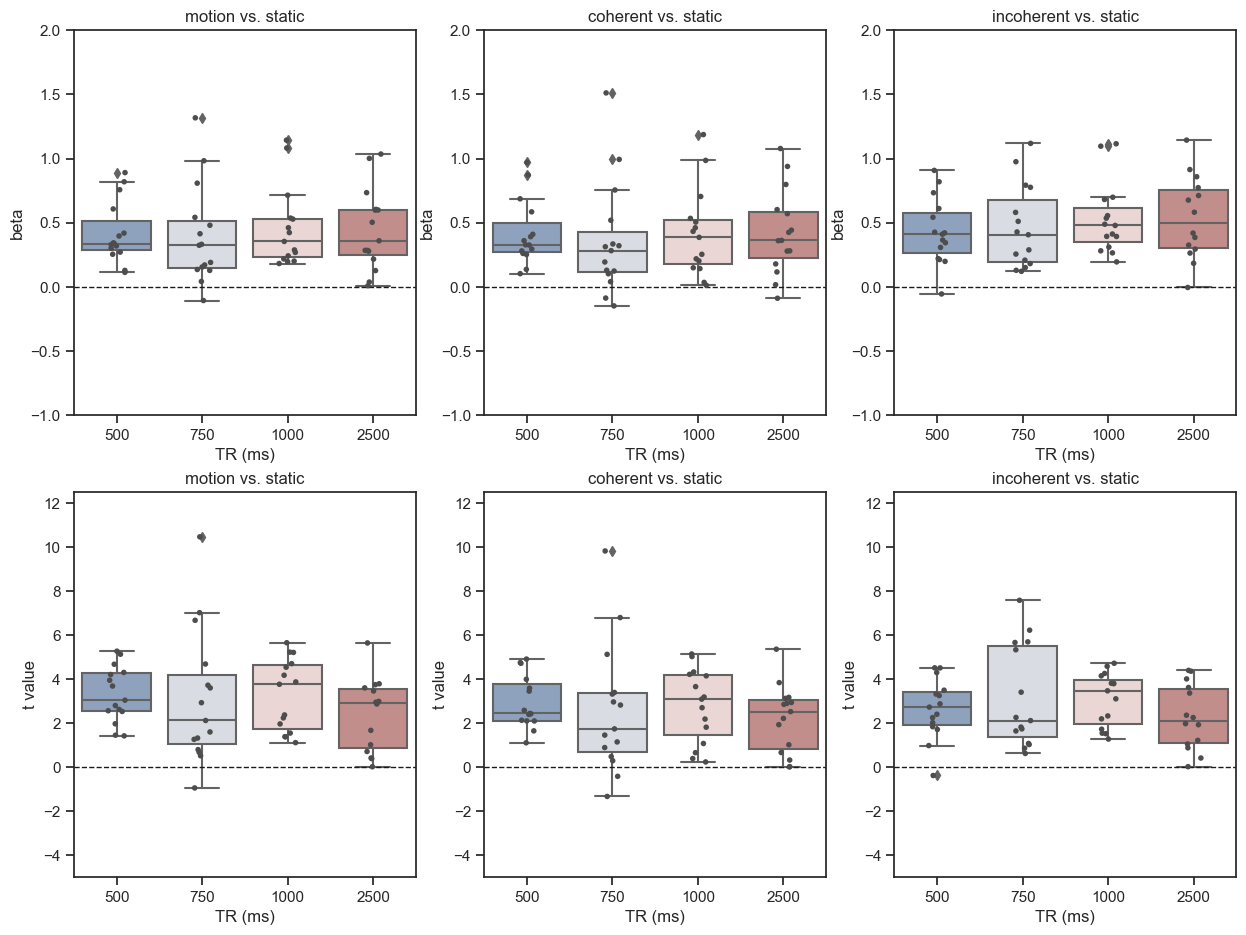

In [ ]:
# Load dataframes for all contrasts to plot big figure
df1 = pd.read_csv(os.path.join("..", "data", f"nilearn-roianalysis-UA-motionMinusStatic.tsv"), sep="\t")
df2 = pd.read_csv(os.path.join("..", "data", f"nilearn-roianalysis-UA-coherentMinusStatic.tsv"), sep="\t")
df3 = pd.read_csv(os.path.join("..", "data", f"nilearn-roianalysis-UA-incoherentMinusStatic.tsv"), sep="\t")

# Exclude all entried with task==AA
df1 = df1[df1["task"] == "UA"]
df2 = df2[df2["task"] == "UA"]
df3 = df3[df3["task"] == "UA"]

# Remove task column
df1 = df1.drop(columns=["task"])
df2 = df2.drop(columns=["task"])
df3 = df3.drop(columns=["task"])

# "Average" 'roi'==V1 L and V1 R
df1.loc[df1["roi"] == "V1 L", "roi"] = "V1"
df1.loc[df1["roi"] == "V1 R", "roi"] = "V1"
df2.loc[df2["roi"] == "V1 L", "roi"] = "V1"
df2.loc[df2["roi"] == "V1 R", "roi"] = "V1"
df3.loc[df3["roi"] == "V1 L", "roi"] = "V1"
df3.loc[df3["roi"] == "V1 R", "roi"] = "V1"

# Average per subject, tr and roi
df1 = df1.groupby(["subject", "tr", "roi"]).mean().reset_index()
df2 = df2.groupby(["subject", "tr", "roi"]).mean().reset_index()
df3 = df3.groupby(["subject", "tr", "roi"]).mean().reset_index()

# Perform a 2x6 subplot figure - 2 rows for beta and t values, 3 columns for each contrast
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 11), sharey=False)

# -------------- SUBPLOT 1 - beta - motionMinusStatic contrast ----------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="beta", data=df1.loc[df1["roi"] == "V1", :], size=4, color=".3", linewidth=0, ax=axes[0, 0])

# boxplot
aux = sns.boxplot(x="tr", y="beta", data=df1.loc[df1["roi"] == "V1", :], palette="vlag", ax=axes[0, 0])
aux.set_title("motion vs. static")
aux.set_ylim(-1, 2)
aux.set_ylabel("beta")
aux.set_xlabel("TR (ms)")

# line in y=0
axes[0, 0].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[0, 0], TR_pairs, data=df1.loc[df1["roi"] == "V1", :], x="tr", y="beta", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()

# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 2 - beta - coherentMinusStatic contrast ----------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="beta", data=df2.loc[df2["roi"] == "V1", :], size=4, color=".3", linewidth=0, ax=axes[0, 1])

# boxplot
aux = sns.boxplot(x="tr", y="beta", data=df2.loc[df2["roi"] == "V1", :], palette="vlag", ax=axes[0, 1])
aux.set_title("coherent vs. static")
aux.set_ylim(-1, 2)
aux.set_ylabel("beta")
aux.set_xlabel("TR (ms)")

# line in y=0
axes[0, 1].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[0, 1], TR_pairs, data=df2.loc[df2["roi"] == "V1", :], x="tr", y="beta", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 3 - beta - incoherentMinusStatic contrast --------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="beta", data=df3.loc[df3["roi"] == "V1", :], size=4, color=".3", linewidth=0, ax=axes[0, 2])

# boxplot
aux = sns.boxplot(x="tr", y="beta", data=df3.loc[df3["roi"] == "V1", :], palette="vlag", ax=axes[0, 2])
aux.set_title("incoherent vs. static")
aux.set_ylim(-1, 2)
aux.set_ylabel("beta")
aux.set_xlabel("TR (ms)")

# line in y=0
axes[0, 2].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[0, 2], TR_pairs, data=df3.loc[df3["roi"] == "V1", :], x="tr", y="beta", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 4 - tval - motionMinusStatic contrast ------------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="tval", data=df1.loc[df1["roi"] == "V1", :], size=4, color=".3", linewidth=0, ax=axes[1, 0])

# boxplot
aux = sns.boxplot(x="tr", y="tval", data=df1.loc[df1["roi"] == "V1", :], palette="vlag", ax=axes[1, 0])
aux.set_title("motion vs. static")
aux.set_ylim(-5, 12.5)
aux.set_ylabel("t value")
aux.set_xlabel("TR (ms)")

# line in y=0
axes[1, 0].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[1, 0], TR_pairs, data=df1.loc[df1["roi"] == "V1", :], x="tr", y="tval", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 5 - tval - coherentMinusStatic contrast ----------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="tval", data=df2.loc[df2["roi"] == "V1", :], size=4, color=".3", linewidth=0, ax=axes[1, 1])

# boxplot
aux = sns.boxplot(x="tr", y="tval", data=df2.loc[df2["roi"] == "V1", :], palette="vlag", ax=axes[1, 1])
aux.set_title("coherent vs. static")
aux.set_ylim(-5, 12.5)
aux.set_ylabel("t value")
aux.set_xlabel("TR (ms)")

# line in y=0
axes[1, 1].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[1, 1], TR_pairs, data=df2.loc[df2["roi"] == "V1", :], x="tr", y="tval", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------- SUBPLOT 6 - tval - incoherentMinusStatic contrast --------------------------------------------------------------------
# add points
sns.stripplot(x="tr", y="tval", data=df3.loc[df3["roi"] == "V1", :], size=4, color=".3", linewidth=0, ax=axes[1, 2])

# boxplot
aux = sns.boxplot(x="tr", y="tval", data=df3.loc[df3["roi"] == "V1", :], palette="vlag", ax=axes[1, 2])
aux.set_title("incoherent vs. static")
aux.set_ylim(-5, 12.5)
aux.set_ylabel("t value")
aux.set_xlabel("TR (ms)")

# line in y=0
axes[1, 2].axhline(y=0, color="k", linestyle="--", linewidth=1)

# statistical comparisons between TRs
annotator = Annotator(axes[1, 2], TR_pairs, data=df3.loc[df3["roi"] == "V1", :], x="tr", y="tval", order=TRs)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=True)
annotator.apply_and_annotate()

In [ ]:
# load dataframe
DF = pd.read_csv(os.path.join("..", "data", f"nilearn-roianalysis-UA-{contrast_name_valid}.tsv"), sep="\t")
DF

,subject,tr,task,roi,beta,tval,zval
0,sub-01,500,UA,hMT+ L,1.034471,5.483909,5.420918
1,sub-01,500,UA,hMT+ R,1.127044,4.922212,4.873059
2,sub-01,500,UA,V1 L,0.162308,0.553786,0.553459
3,sub-01,500,UA,V1 R,0.278395,1.415901,1.414097
4,sub-01,750,UA,hMT+ L,0.816446,4.837178,4.761856
...,...,...,...,...,...,...,...
235,sub-23,1000,UA,V1 R,0.432506,2.594101,2.577286
236,sub-23,2500,UA,hMT+ L,0.599949,1.981135,1.910496
237,sub-23,2500,UA,hMT+ R,0.741327,2.988768,2.888535
238,sub-23,2500,UA,V1 L,0.387713,1.695874,1.676986


In [ ]:
# Exclude all entries with task=AA
DF = DF[DF["task"] == "UA"]
DF

,subject,tr,task,roi,beta,tval,zval
0,sub-01,500,UA,hMT+ L,1.034471,5.483909,5.420918
1,sub-01,500,UA,hMT+ R,1.127044,4.922212,4.873059
2,sub-01,500,UA,V1 L,0.162308,0.553786,0.553459
3,sub-01,500,UA,V1 R,0.278395,1.415901,1.414097
4,sub-01,750,UA,hMT+ L,0.816446,4.837178,4.761856
...,...,...,...,...,...,...,...
235,sub-23,1000,UA,V1 R,0.432506,2.594101,2.577286
236,sub-23,2500,UA,hMT+ L,0.599949,1.981135,1.910496
237,sub-23,2500,UA,hMT+ R,0.741327,2.988768,2.888535
238,sub-23,2500,UA,V1 L,0.387713,1.695874,1.676986


In [ ]:
# Remove task column
DF = DF.drop(columns=["task"])

In [ ]:
# "Average" 'roi'==hMT+ L and hMT+ R
DF.loc[DF["roi"] == "hMT+ L", "roi"] = "hMT+"
DF.loc[DF["roi"] == "hMT+ R", "roi"] = "hMT+"

# "Average" 'roi'==V1 L and V1 R
DF.loc[DF["roi"] == "V1 L", "roi"] = "V1"
DF.loc[DF["roi"] == "V1 R", "roi"] = "V1"

DF

,subject,tr,roi,beta,tval,zval
0,sub-01,500,hMT+,1.034471,5.483909,5.420918
1,sub-01,500,hMT+,1.127044,4.922212,4.873059
2,sub-01,500,V1,0.162308,0.553786,0.553459
3,sub-01,500,V1,0.278395,1.415901,1.414097
4,sub-01,750,hMT+,0.816446,4.837178,4.761856
...,...,...,...,...,...,...
235,sub-23,1000,V1,0.432506,2.594101,2.577286
236,sub-23,2500,hMT+,0.599949,1.981135,1.910496
237,sub-23,2500,hMT+,0.741327,2.988768,2.888535
238,sub-23,2500,V1,0.387713,1.695874,1.676986


In [ ]:
# Average per subject, tr and roi
DF = DF.groupby(["subject", "tr", "roi"]).mean().reset_index()
DF

,subject,tr,roi,beta,tval,zval
0,sub-01,500,V1,0.220352,0.984843,0.983778
1,sub-01,500,hMT+,1.080757,5.203061,5.146988
2,sub-01,750,V1,0.580737,3.412122,3.388349
3,sub-01,750,hMT+,0.791333,4.433068,4.372061
4,sub-01,1000,V1,0.555203,4.262713,4.199965
...,...,...,...,...,...,...
115,sub-23,750,hMT+,0.748732,3.183783,3.159248
116,sub-23,1000,V1,0.412111,2.200079,2.188221
117,sub-23,1000,hMT+,1.029967,4.101520,4.023622
118,sub-23,2500,V1,0.385652,1.933591,1.908099


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.160e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.030e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.043e-01 U_stat=1.600e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.050e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.476e-01 U_stat=1.570e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.476e-01 U_stat=1.570e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
    

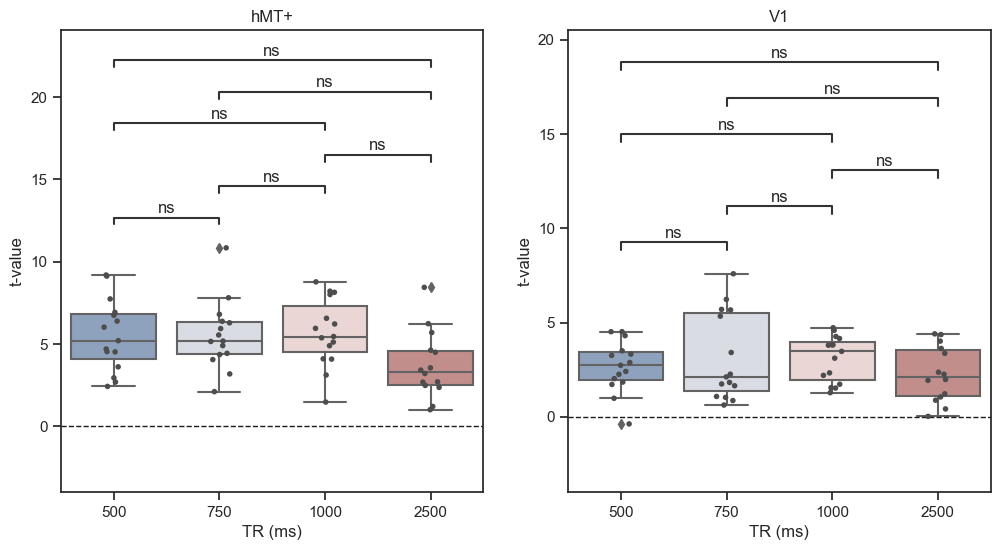

In [ ]:
# perform a boxplot of the t values for each ROI, splitting per TR

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for ii in range(2):
    # add points
    sns.stripplot(x="tr", y="tval", data=DF.loc[DF["roi"] == roi_labels[ii], :], size=4, color=".3", linewidth=0, ax=ax[ii])

    # boxplot
    aux = sns.boxplot(x="tr", y="tval", data=DF.loc[DF["roi"] == roi_labels[ii], :], palette="vlag", ax=ax[ii])
    aux.set_title(roi_labels[ii])
    aux.set_ylim(-4, 17)
    aux.set_ylabel("t-value")
    aux.set_xlabel("TR (ms)")

    # line in y=0
    ax[ii].axhline(y=0, color="k", linestyle="--", linewidth=1)

    # statistical comparisons between TRs
    annotator = Annotator(ax[ii], TR_pairs, data=DF.loc[DF["roi"] == roi_labels[ii], :], x="tr", y="tval", order=TRs)
    annotator.configure(
        test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni", hide_non_significant=False
    )
    annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.040e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.120e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.210e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.010e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.210e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.070e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
    

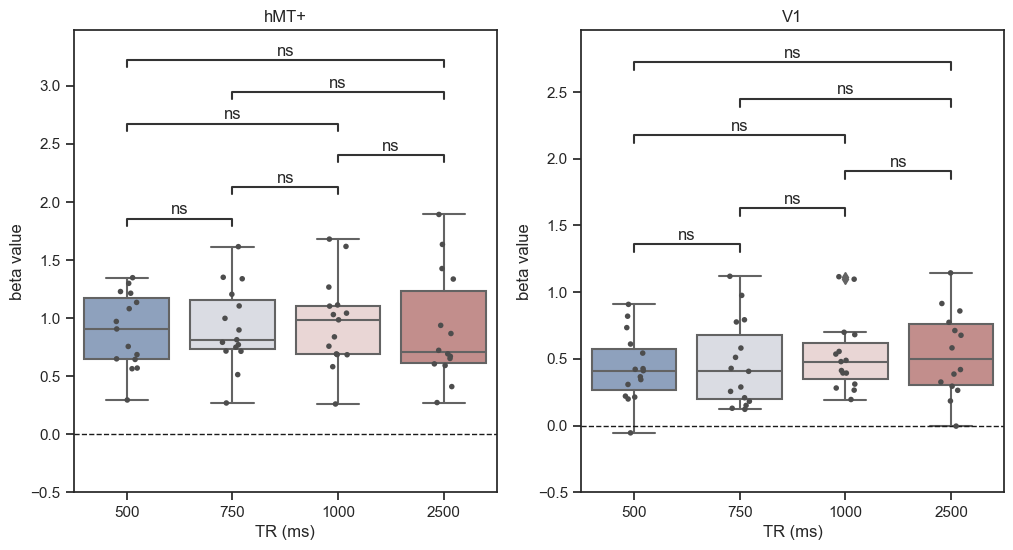

In [ ]:
# perform a boxplot of the beta values for each ROI, splitting per TR

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for ii in range(2):
    # add points
    sns.stripplot(x="tr", y="beta", data=DF.loc[DF["roi"] == roi_labels[ii], :], size=4, color=".3", linewidth=0, ax=ax[ii])

    # boxplot
    aux = sns.boxplot(x="tr", y="beta", data=DF.loc[DF["roi"] == roi_labels[ii], :], palette="vlag", ax=ax[ii])
    aux.set_title(roi_labels[ii])
    aux.set_ylim(-0.5, 2.5)
    aux.set_ylabel("beta value")
    aux.set_xlabel("TR (ms)")

    # line in y=0
    ax[ii].axhline(y=0, color="k", linestyle="--", linewidth=1)

    # statistical comparisons between TRs
    annotator = Annotator(ax[ii], TR_pairs, data=DF.loc[DF["roi"] == roi_labels[ii], :], x="tr", y="beta", order=TRs)
    annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni")
    annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.890e-01 U_stat=1.550e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.210e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.890e-01 U_stat=1.550e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.470e-01 U_stat=1.560e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.074e-01 U_stat=1.600e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.456e-03 U_stat=1.960e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
    

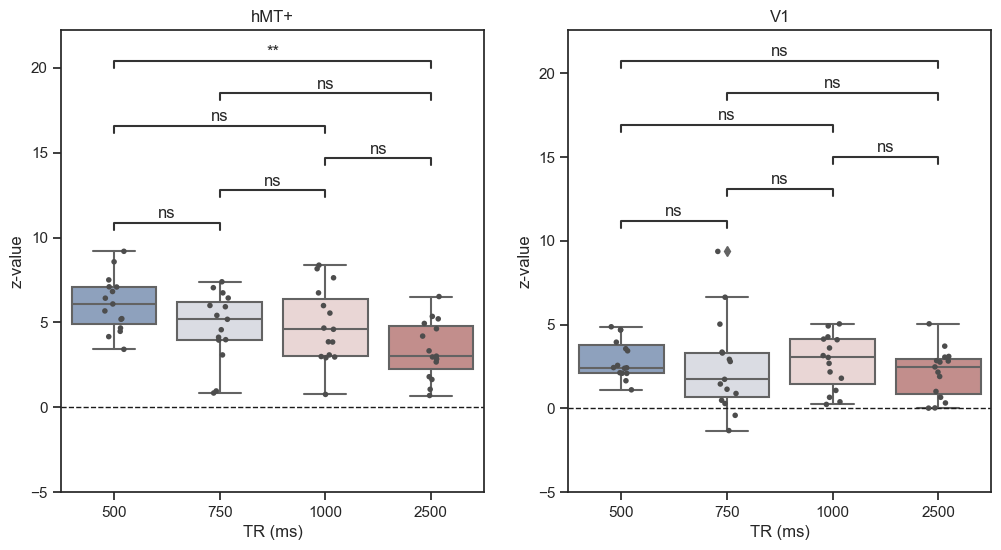

In [ ]:
# perform a boxplot of the z values for each ROI, splitting per TR

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for ii in range(2):
    # add points
    sns.stripplot(x="tr", y="zval", data=DF.loc[DF["roi"] == roi_labels[ii], :], size=4, color=".3", linewidth=0, ax=ax[ii])

    # boxplot
    aux = sns.boxplot(x="tr", y="zval", data=DF.loc[DF["roi"] == roi_labels[ii], :], palette="vlag", ax=ax[ii])
    aux.set_title(roi_labels[ii])
    aux.set_ylim(-5, 16)
    aux.set_ylabel("z-value")
    aux.set_xlabel("TR (ms)")

    # line in y=0
    ax[ii].axhline(y=0, color="k", linestyle="--", linewidth=1)

    # statistical comparisons between TRs
    annotator = Annotator(ax[ii], TR_pairs, data=DF.loc[DF["roi"] == roi_labels[ii], :], x="tr", y="zval", order=TRs)
    annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=1, comparisons_correction="bonferroni")
    annotator.apply_and_annotate()